In [1]:
# SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14,6)

# load processed data
df = pd.read_csv('../data/processed/forecast_ready.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"Loaded {df.shape[0]:,} rows")

Loaded 108,638 rows


In [2]:
# AGGREGATE TO DAILY DEMAND PER CATEGORY

# Daily order count per category
daily_demand = (df.groupby(['order_date', 'product_category_name_english'])
                .agg(
                    order_count=('order_id', 'nunique'),
                    total_revenue=('price', 'sum'),
                    total_items=('product_id', 'count')
                )
                .reset_index())

print(f"Daily demand dataset: {daily_demand.shape[0]:,}")
print(f"\nSample:")
daily_demand.head(10)

Daily demand dataset: 18,311

Sample:


,order_date,product_category_name_english,order_count,total_revenue,total_items
0,2016-09-15,health_beauty,1,134.97,3
1,2016-10-03,fashion_shoes,1,29.99,1
2,2016-10-03,furniture_decor,2,194.80,2
3,2016-10-03,sports_leisure,2,58.39,2
4,2016-10-03,toys,1,128.90,1
5,2016-10-03,watches_gifts,1,29.90,1
6,2016-10-04,air_conditioning,3,749.69,4
7,2016-10-04,auto,1,9.90,1
8,2016-10-04,baby,2,279.79,3
9,2016-10-04,bed_bath_table,1,159.80,2


In [3]:
# FOCUS ON ONE CATEGORY 

# Pick top category to develop approach
target_category = 'bed_bath_table'
cat_daily = daily_demand[daily_demand['product_category_name_english'] == target_category].copy()

# Fill missing date with zero
# not missing data but no order/ zero demand
date_range = pd.date_range(start=cat_daily['order_date'].min(),
                           end=cat_daily['order_date'].max(),
                           freq='D')

cat_daily = (cat_daily.set_index('order_date')
             .reindex(date_range)
             .fillna({'order_count': 0, 'total_revenue': 0, 'total_items': 0})
             .rename_axis('order_date')
             .reset_index())

cat_daily['product_category_name_english'] = target_category

print(f"Date range: {cat_daily['order_date'].min()} to {cat_daily['order_date'].max()}")
print(f"Total Daily: {len(cat_daily)}")
print(f"Days with zero orders: {(cat_daily['order_count'] == 0).sum()}")

Date range: 2016-10-04 00:00:00 to 2018-08-28 00:00:00
Total Daily: 694
Days with zero orders: 97


Training: 634 days (2016-10-04 00:00:00 to 2018-06-29 00:00:00)
Testing: 60 days (2018-06-30 00:00:00 to 2018-08-28 00:00:00)


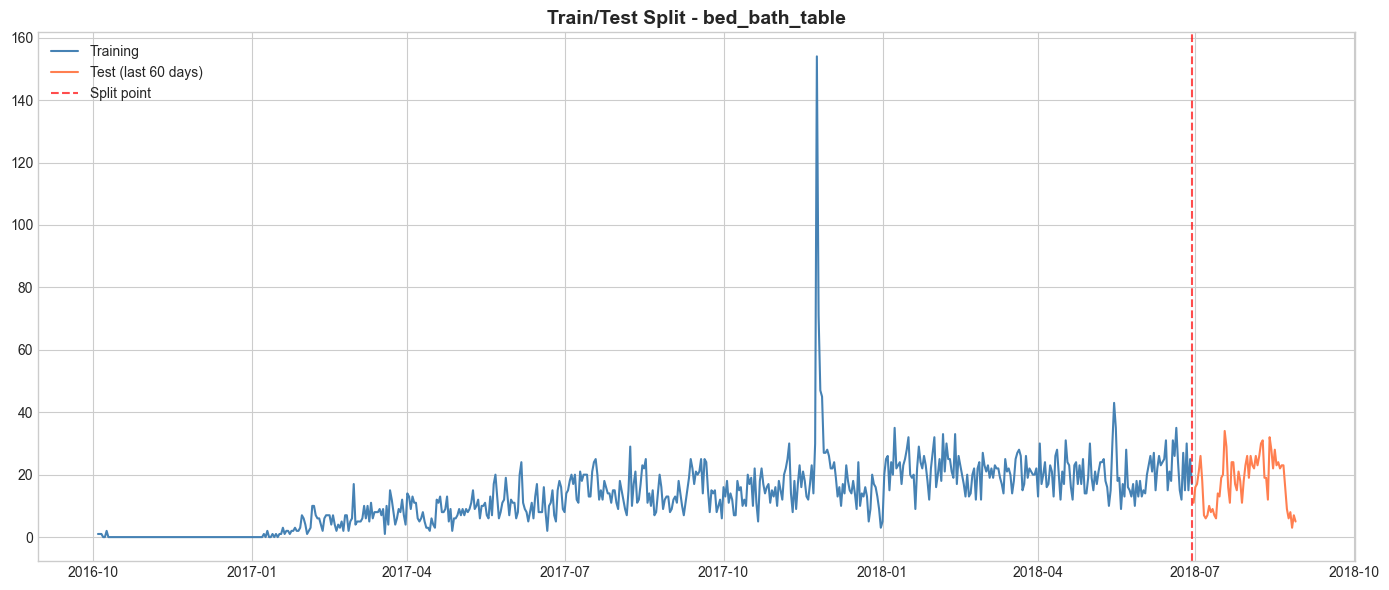

In [4]:
# TRAIN/TEST SPLIT for time-series

# Last 60 days for test set
split_date = cat_daily['order_date'].max() - pd.Timedelta(days=60)

train = cat_daily[cat_daily['order_date'] <= split_date].copy()
test = cat_daily[cat_daily['order_date'] > split_date].copy()

print(f"Training: {len(train)} days ({train['order_date'].min()} to {train['order_date'].max()})")
print(f"Testing: {len(test)} days ({test['order_date'].min()} to {test['order_date'].max()})")

# visual
fig, ax =plt.subplots(figsize=(14,6))
ax.plot(train['order_date'], train['order_count'], label='Training', color='steelblue')
ax.plot(test['order_date'], test['order_count'], label='Test (last 60 days)', color='coral')
ax.axvline(x=split_date, color='red', linestyle='--', alpha=0.7, label='Split point')
ax.set_title(f'Train/Test Split - {target_category}', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# BASELINE 
# Model 1: Naive Bayes
# predict tomorrow's demand = average of same weekday over last 4 weeks
def naive_baseline(train, test):
    predictions = []
    for _, row in test.iterrows():
        day_of_week = row['order_date'].dayofweek
        # average of same weekday from last4 weeks of training
        same_day = train[train['order_date'].dt.dayofweek == day_of_week].tail(4)
        pred = same_day['order_count'].mean()
        predictions.append(pred)
    return predictions

test['baseline_pred'] = naive_baseline(train, test)

baseline_mae = mean_absolute_error(test['order_count'], test['baseline_pred'])
baseline_rmse = np.sqrt(mean_squared_error(test['order_count'], test['baseline_pred']))

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline MAE: 6.86
Baseline RMSE: 8.80


In [9]:
# Feature Engineering fo XGBoost

def create_features(data):
    """Create time-based features for ML model"""
    df = data.copy()
    df['dayofweek'] = df['order_date'].dt.dayofweek
    df['month'] = df['order_date'].dt.month
    df['day'] = df['order_date'].dt.day
    df['weekofyear'] = df['order_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['order_date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['order_date'].dt.is_month_end.astype(int)

    # Lag features - what happent in recent days
    for lag in [7, 14, 28]:
        df[f'lag_{lag}'] = df['order_count'].shift(lag)

    # Rolling averages - smoothed recent history
    for window in [7, 14, 30]:
        df[f'rolling_mean_{window}'] = df['order_count'].shift(1).rolling(window=window).mean()
    
    return df

#Apply to full data set and re-split
cat_featured = create_features(cat_daily)

#Drop rows with NaN form lag/rolling features
cat_featured = cat_featured.dropna()

#Re-split
train_feat = cat_featured[cat_featured['order_date'] <= split_date]
test_feat = cat_featured[cat_featured['order_date'] > split_date]

feature_cols = ['dayofweek', 'month', 'day', 'weekofyear', 'is_weekend',
                'is_month_start', 'is_month_end',
                'lag_7', 'lag_14', 'lag_28',
                'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']

print(f"Features: {feature_cols}")
print(f"Training samples: {len(train_feat)}")
print(f"Test samples: {len(test_feat)}")

Features: ['dayofweek', 'month', 'day', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']
Training samples: 604
Test samples: 60


In [10]:
# Train XGBoost

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(
    train_feat[feature_cols],
    train_feat['order_count'],
    eval_set=[(test_feat[feature_cols], test_feat['order_count'])],
    verbose=False
)

test_feat = test_feat.copy()
test_feat['xgb_pred'] = model_xgb.predict(test_feat[feature_cols]).clip(min=0)

xgb_mae = mean_absolute_error(test_feat['order_count'], test_feat['xgb_pred'])
xgb_rmse = np.sqrt(mean_squared_error(test_feat['order_count'], test_feat['xgb_pred']))

print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

XGBoost MAE: 7.97
XGBoost RMSE: 10.55


In [11]:
# COMPARE MODELS

# Results summary
results = pd.DataFrame({
    'Model': ['Naive Baseline', 'XGBoost'],
    'MAE': [baseline_mae, xgb_mae],
    'RMSE': [baseline_rmse, xgb_rmse]
}).round(2)

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(results.to_string(index=False))
print(f"\nBest model by MAE: {results.loc[results['MAE'].idxmin(), 'Model']}")


MODEL COMPARISON
         Model  MAE  RMSE
Naive Baseline 6.86  8.80
       XGBoost 7.97 10.55

Best model by MAE: Naive Baseline


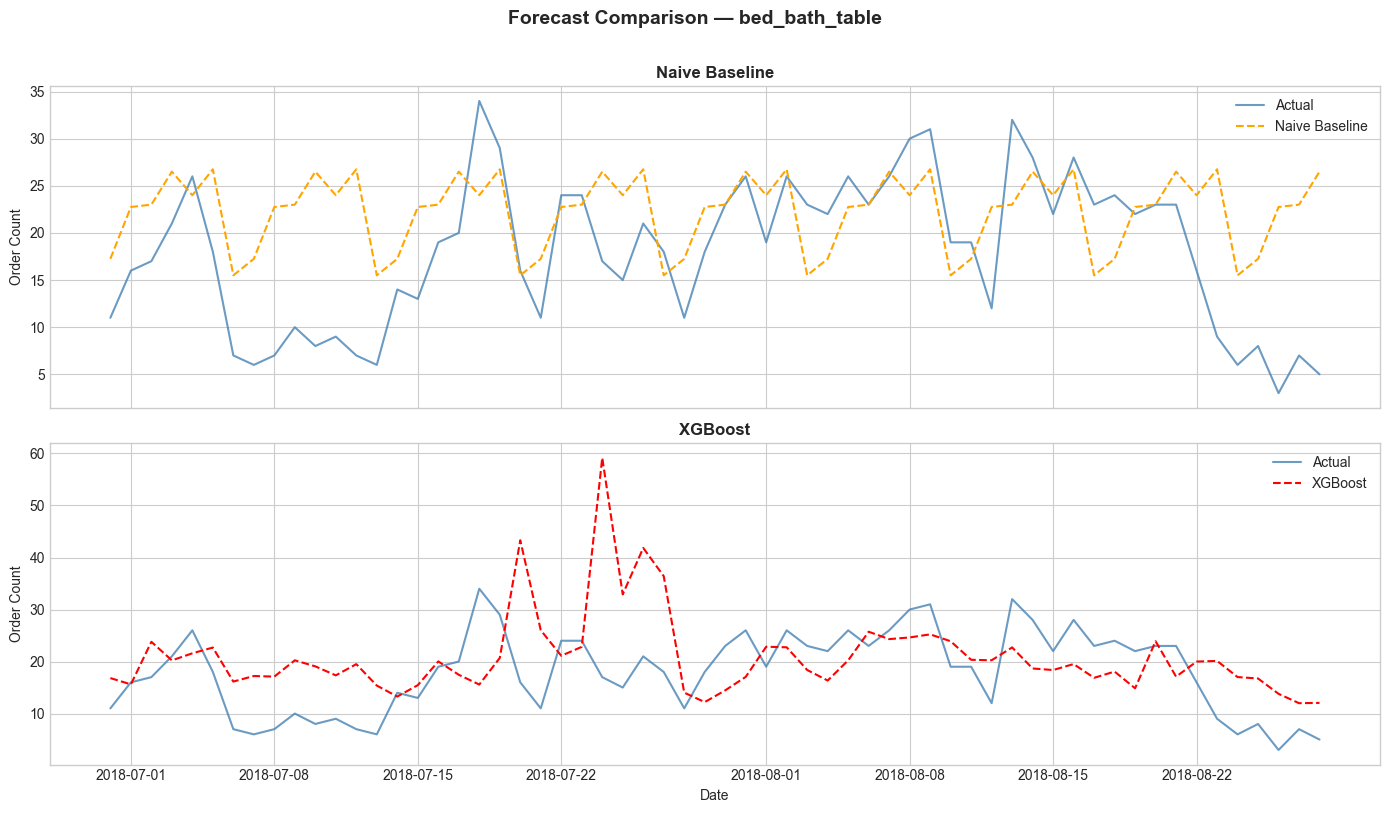

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

models = [
    ('Naive Baseline', test['baseline_pred'], 'orange'),
    ('XGBoost', test_feat['xgb_pred'], 'red')
]


for ax, (name, preds, color) in zip(axes, models):
    ax.plot(test['order_date'], test['order_count'], 
            color='steelblue', linewidth=1.5, label='Actual', alpha=0.8)
    
    if name == 'XGBoost':
        ax.plot(test_feat['order_date'], preds, 
                color=color, linewidth=1.5, linestyle='--', label=name)
    else:
        ax.plot(test['order_date'], preds, 
                color=color, linewidth=1.5, linestyle='--', label=name)
    
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_ylabel('Order Count')

axes[1].set_xlabel('Date')
plt.suptitle(f'Forecast Comparison — {target_category}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

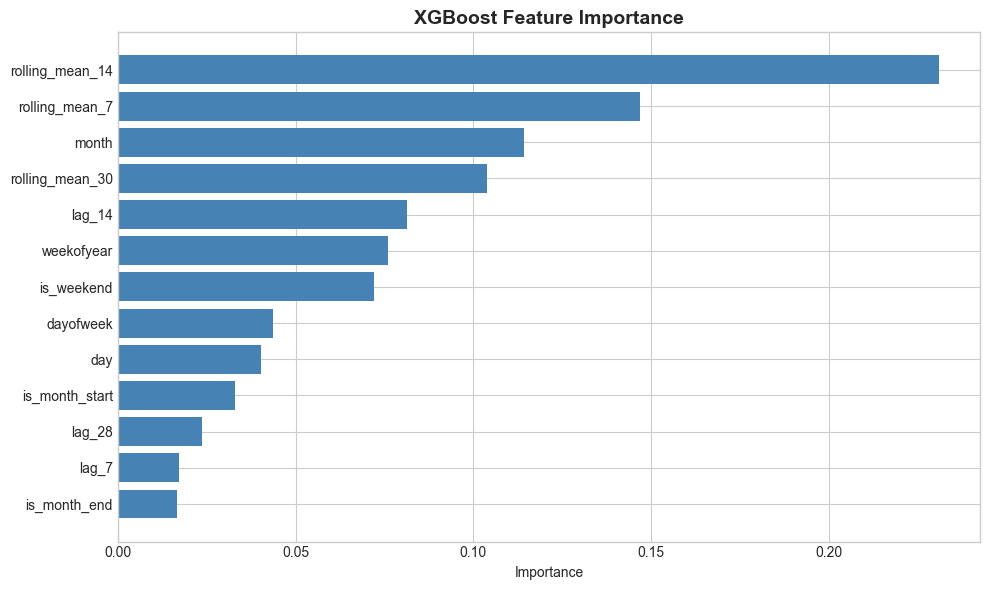

        feature  importance
rolling_mean_14    0.231054
 rolling_mean_7    0.146881
          month    0.114327
rolling_mean_30    0.103869
         lag_14    0.081319
     weekofyear    0.076053
     is_weekend    0.072142
      dayofweek    0.043596
            day    0.040264
 is_month_start    0.033042
         lag_28    0.023765
          lag_7    0.017136
   is_month_end    0.016554


In [14]:
# FEATURE IMPORTANCE (UNDERSTANDING WHAT XGBOOST IS USING)

# What feature matter most?
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance.to_string(index=False))

## Modeling Summary

### Results
| Model | MAE | RMSE |
|-------|-----|------|
| Naive Baseline | 6.86 | 8.80 |
| XGBoost | 7.97 | 10.55 |

### Key Insights
- Baseline outperformed XGBoost on MAE, demonstrating that model 
  complexity doesn't guarantee better performance with limited data
- XGBoost tracks demand patterns more closely visually but produces 
  larger errors during anomalous periods
- Top features: rolling_mean_14, rolling_mean_7, month
- With more data and external features (promotions, holidays), 
  XGBoost would likely surpass the baseline

### Next Steps
- Use the best available forecast to drive inventory decisions
- Phase 3 will translate these predictions into optimal stock levels